# ***Multi-Output Regressor (GBM)***

Model memprediksi **11 statistik profil pemain sekaligus** dari 1 vektor sesi.

| Input X (8 fitur) | Output Y (11 target) |
|---|---|
| tpc, er, hr, cr, nmr, gur, moves, score | exp_tpc, exp_er, exp_hr, exp_cr, exp_nmr, exp_gur, exp_score, speed_idx, accuracy_idx, consistency_idx, independence_idx |

**Pipeline:**
1. Synthetic data 5000 sampel (5 archetype × 1000)
2. Split 60% / 20% / 20% (train / val / test)
3. Validation curves per hyperparameter
4. `RandomizedSearchCV` n_iter=40, cv=5
5. Evaluasi: per-output R², RMSE, scatter plot, residual
6. Feature importance (RFC: Gini, GBM: Permutation)
7. Final test evaluation + save PKL

In [1]:
import numpy as np
import pandas as pd
import json, os, pickle, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, KFold, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
print('✓ Libraries loaded')

✓ Libraries loaded


In [2]:
# ── Naming & Grouping ──────────────────────────────────────────────
FEATURE_NAMES = ['tpc', 'er', 'hr', 'cr', 'nmr', 'gur', 'moves', 'score']
FEATURE_DESC  = [
    'Time-per-cell (s)', 'Error rate/move', 'Hint rate/move',
    'Completion rate', 'Near-miss rate', 'Guessing rate',
    'Avg moves', 'Score'
]
TARGET_NAMES = [
    'exp_tpc', 'exp_er',  'exp_hr',  'exp_cr',
    'exp_nmr', 'exp_gur', 'exp_score',
    'speed_idx', 'accuracy_idx', 'consistency_idx', 'independence_idx'
]
# Targets 0-6 = raw rate predictions, 7-10 = skill index (0-100)
RATE_IDX  = list(range(7))
INDEX_IDX = list(range(7, 11))

DATA_FILE = 'sudoku_data.json'

print('Features :', FEATURE_NAMES)
print('Targets  :', TARGET_NAMES)

Features : ['tpc', 'er', 'hr', 'cr', 'nmr', 'gur', 'moves', 'score']
Targets  : ['exp_tpc', 'exp_er', 'exp_hr', 'exp_cr', 'exp_nmr', 'exp_gur', 'exp_score', 'speed_idx', 'accuracy_idx', 'consistency_idx', 'independence_idx']


In [3]:
# ═══════════════════════════════════════════════════════════════
# DATA GENERATION
# Formula target identik dengan _ml_targets() di Sudoku.py
# ═══════════════════════════════════════════════════════════════

def make_data(n_per_arch: int = 1000, noise: float = 0.07, seed: int = 42):
    """
    5 archetype × n_per_arch samples.
    X: noisy session observation  (8 features)
    Y: expected/smoothed profile  (11 targets)

    Targets 0-6  = kemiripan X dengan noise kecil (model belajar smooth)
    Targets 7-10 = transformasi deterministik + noise:
        speed_idx      = clip(100 - tpc*8,   0, 100)
        accuracy_idx   = clip(100 - er*250,  0, 100)
        consistency_idx= clip(cr*100,        0, 100)
        independence_idx= clip(100 - hr*120, 0, 100)
    """
    rng = np.random.default_rng(seed)

    # (mean, std, min, max) per feature
    archetypes = {
        'Speedrunner':  dict(
            tpc=(2.5,0.8,1.0,6.0),   er=(0.020,0.012,0.0,0.05),
            hr=(0.018,0.010,0.0,0.04),cr=(0.97,0.03,0.88,1.0),
            nmr=(0.35,0.15,0.0,0.70), gur=(0.08,0.05,0.0,0.22),
            moves=(32,6,8,55),        score=(820,90,350,1300)),
        'Careful':      dict(
            tpc=(19,5,10,35),         er=(0.040,0.020,0.0,0.09),
            hr=(0.035,0.018,0.0,0.08),cr=(0.94,0.05,0.78,1.0),
            nmr=(0.55,0.20,0.0,1.0),  gur=(0.10,0.06,0.0,0.26),
            moves=(38,7,14,60),       score=(480,100,180,760)),
        'Learner':      dict(
            tpc=(8.5,2.5,3.0,16.0),  er=(0.16,0.05,0.04,0.32),
            hr=(0.19,0.06,0.04,0.36),cr=(0.70,0.15,0.25,1.0),
            nmr=(0.50,0.20,0.0,1.0), gur=(0.30,0.12,0.0,0.65),
            moves=(28,8,8,56),        score=(280,100,0,620)),
        'Struggling':   dict(
            tpc=(22,7,7,42),          er=(0.42,0.10,0.18,0.65),
            hr=(0.46,0.10,0.18,0.68), cr=(0.28,0.14,0.0,0.62),
            nmr=(0.35,0.18,0.0,0.78), gur=(0.75,0.15,0.28,1.0),
            moves=(24,10,4,58),        score=(80,70,0,320)),
        'Inconsistent': dict(
            tpc=(9,6,1.5,26),         er=(0.26,0.12,0.02,0.56),
            hr=(0.22,0.11,0.0,0.52),  cr=(0.55,0.22,0.0,1.0),
            nmr=(0.55,0.25,0.0,1.0),  gur=(0.50,0.22,0.0,1.0),
            moves=(27,12,4,58),        score=(210,150,0,720)),
    }

    def _s(p, k, n=n_per_arch):
        m, s, lo, hi = p[k]
        return np.clip(rng.normal(m, s, n), lo, hi)

    Xs, Ys = [], []
    for name, p in archetypes.items():
        tpc = _s(p,'tpc'); er  = _s(p,'er');  hr  = _s(p,'hr')
        cr  = _s(p,'cr');  nmr = _s(p,'nmr'); gur = _s(p,'gur')
        mv  = _s(p,'moves'); sc = _s(p,'score')

        X = np.column_stack([tpc, er, hr, cr, nmr, gur, mv, sc])

        n = n_per_arch
        def nz(s=1.0): return rng.normal(0, noise * s, n)

        # Targets 0-6: smoothed versions of X features
        e_tpc = np.clip(tpc*(1+nz(0.8)),   0.2, 42.0)
        e_er  = np.clip(er *(1+nz(1.5)),   0.0,  0.82)
        e_hr  = np.clip(hr *(1+nz(1.5)),   0.0,  0.82)
        e_cr  = np.clip(cr + nz(0.3),       0.0,  1.0)
        e_nmr = np.clip(nmr*(1+nz(1.5)),   0.0,  1.0)
        e_gur = np.clip(gur*(1+nz(1.5)),   0.0,  1.0)
        e_sc  = np.clip(sc *(1+nz(0.8)),   0.0, 1500.0)

        # Targets 7-10: skill indices (exact formula from Sudoku.py)
        sp_idx = np.clip(100 - e_tpc*8,   0.0, 100.0)
        ac_idx = np.clip(100 - e_er*250,  0.0, 100.0)
        co_idx = np.clip(e_cr*100,         0.0, 100.0)
        in_idx = np.clip(100 - e_hr*120,  0.0, 100.0)

        Y = np.column_stack([
            e_tpc,e_er,e_hr,e_cr,e_nmr,e_gur,e_sc,
            sp_idx,ac_idx,co_idx,in_idx
        ])
        Xs.append(X); Ys.append(Y)

    X_all = np.vstack(Xs); Y_all = np.vstack(Ys)
    idx = rng.permutation(len(X_all))
    return X_all[idx], Y_all[idx]


def load_real_data(path=DATA_FILE):
    """Load sesi nyata dari sudoku_data.json (opsional)."""
    if not os.path.exists(path):
        print('ℹ sudoku_data.json tidak ditemukan — hanya data sintetis')
        return None, None
    with open(path) as f:
        data = json.load(f)
    Xm, Ym = [], []
    for payload in data.get('players', {}).values():
        for s in payload.get('sessions', []):
            mv  = max(s.get('moves',1), 1)
            tpc = s.get('total_time',0) / mv
            er  = s.get('errors',0) / mv
            hr  = s.get('hints_used',0) / mv
            cr  = 1.0 if s.get('completed') else 0.0
            te  = max(s.get('errors',0), 1)
            nmr = s.get('near_miss',0) / te
            gur = s.get('guessing',0) / te
            sc  = float(s.get('score',0) or 0)
            Xm.append([tpc,er,hr,cr,nmr,gur,float(mv),sc])
            Ym.append([
                max(0.2,tpc),max(0,er),max(0,hr),max(0,min(1,cr)),
                max(0,nmr),max(0,gur),max(0,sc),
                max(0,min(100,100-tpc*8)),  max(0,min(100,100-er*250)),
                max(0,min(100,cr*100)),     max(0,min(100,100-hr*120))
            ])
    if not Xm:
        return None, None
    print(f'✓ Real data: {len(Xm)} sesi')
    return np.array(Xm,dtype=float), np.array(Ym,dtype=float)


X, Y     = make_data(n_per_arch=1000)
Xr, Yr   = load_real_data()
if Xr is not None:
    X = np.vstack([X, Xr])
    Y = np.vstack([Y, Yr])

print(f'Total  X={X.shape}  Y={Y.shape}')
print(f'Archetype : 5 × 1000 = 5000 sintetis')

✓ Real data: 31 sesi
Total  X=(5031, 8)  Y=(5031, 11)
Archetype : 5 × 1000 = 5000 sintetis


=== Input Feature Statistics ===
            tpc        er        hr        cr       nmr       gur     moves     score
count  5031.000  5031.000  5031.000  5031.000  5031.000  5031.000  5031.000  5031.000
mean     12.193     0.179     0.184     0.689     0.458     0.344    29.924   382.915
std       8.501     0.164     0.174     0.289     0.221     0.283     9.973   296.898
min       0.604     0.000     0.000     0.000     0.000     0.000     4.000     0.000
25%       4.200     0.034     0.029     0.451     0.299     0.100    23.639   150.742
50%      10.552     0.140     0.146     0.766     0.445     0.258    30.410   325.071
75%      18.706     0.298     0.296     0.951     0.610     0.579    36.918   551.517
max      42.000     0.650     0.680     1.000     1.000     1.000    59.068  2956.000


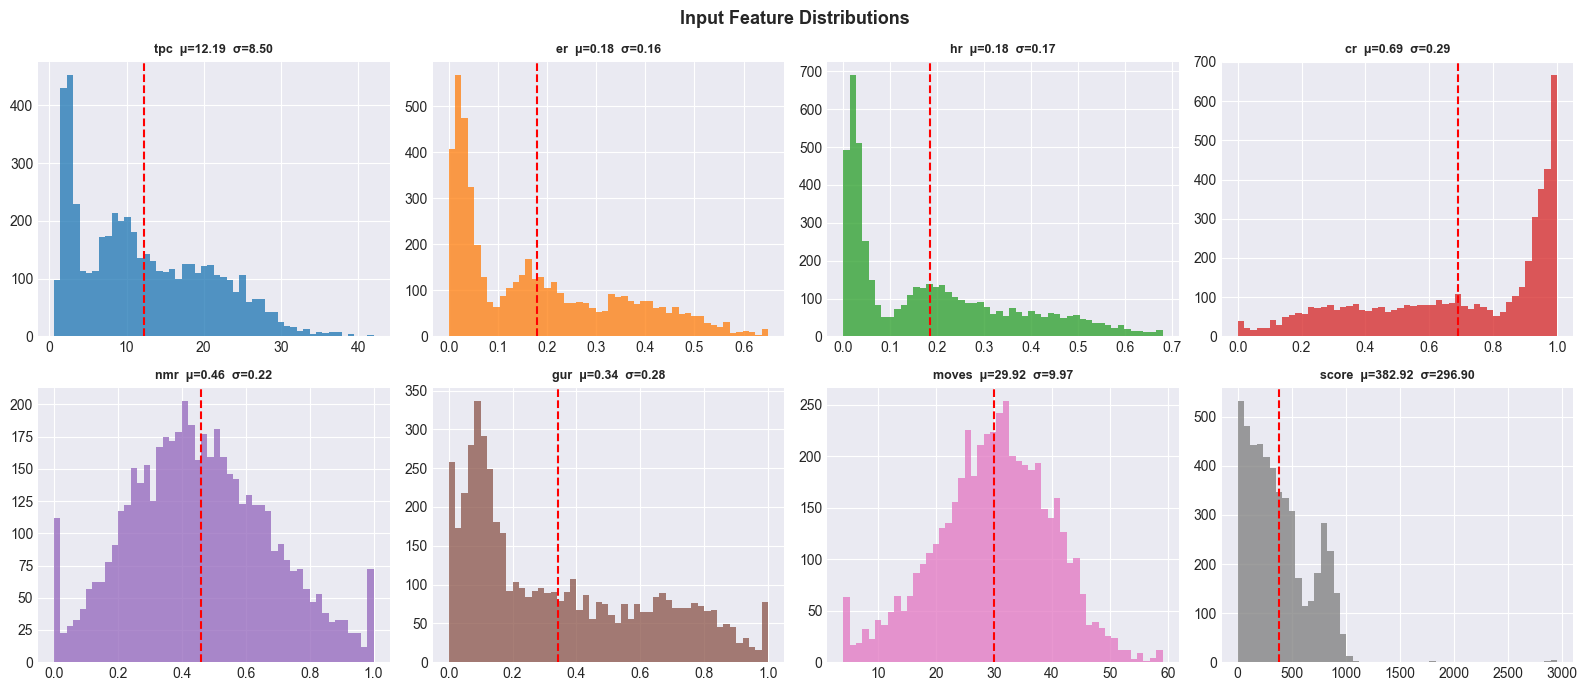

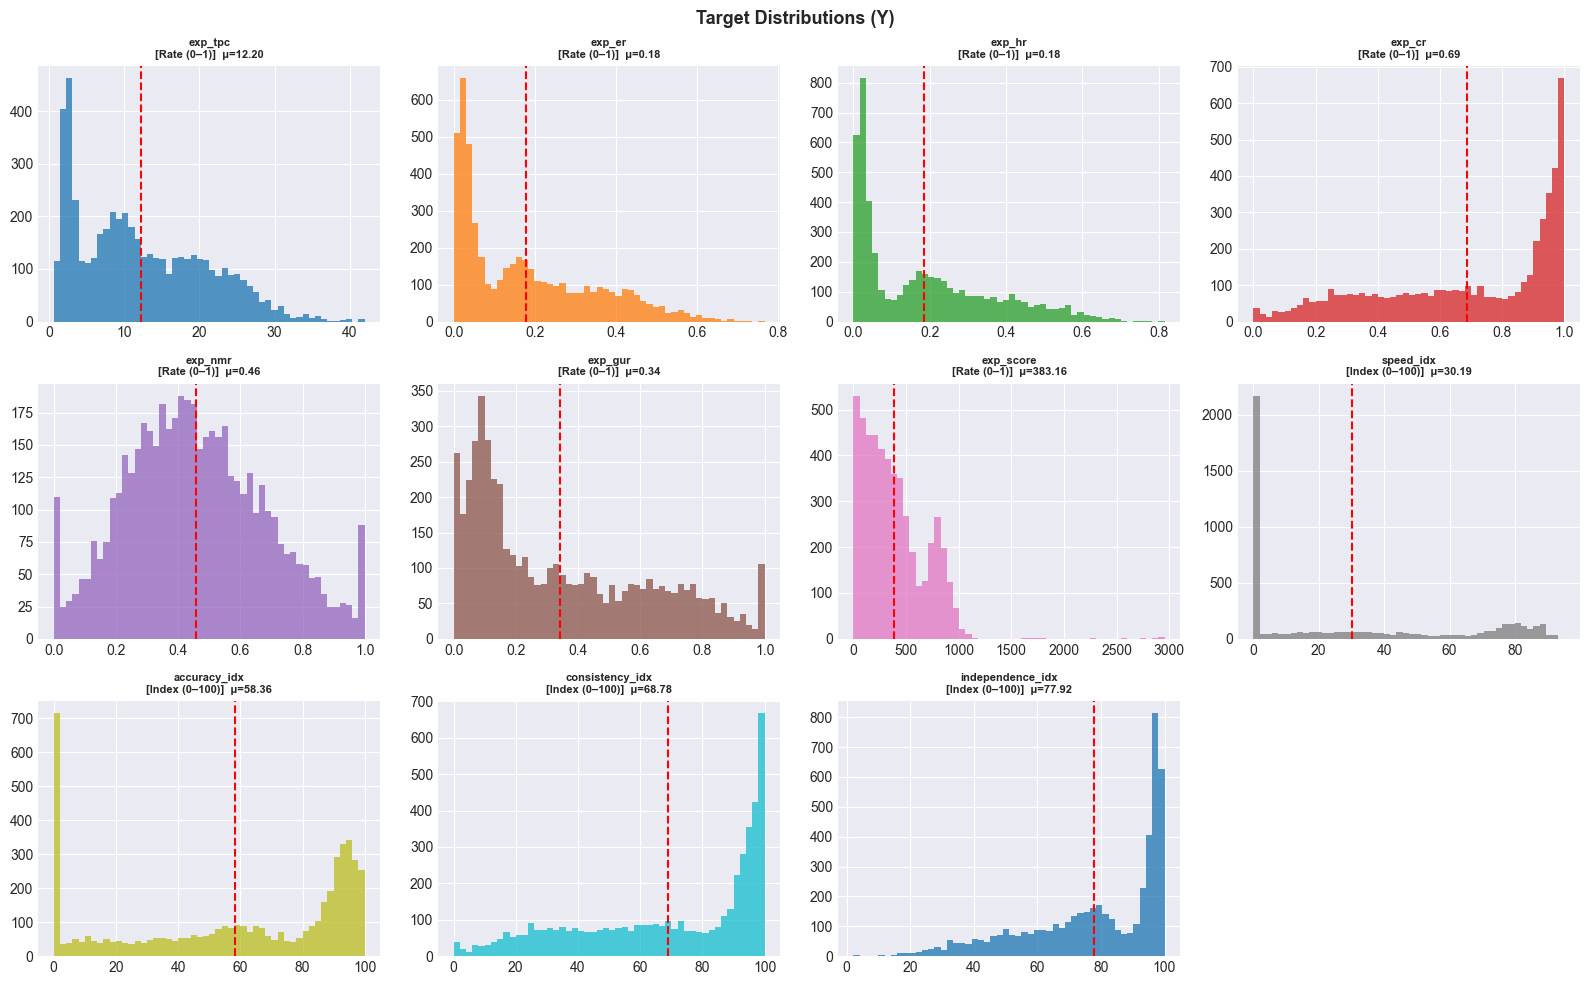

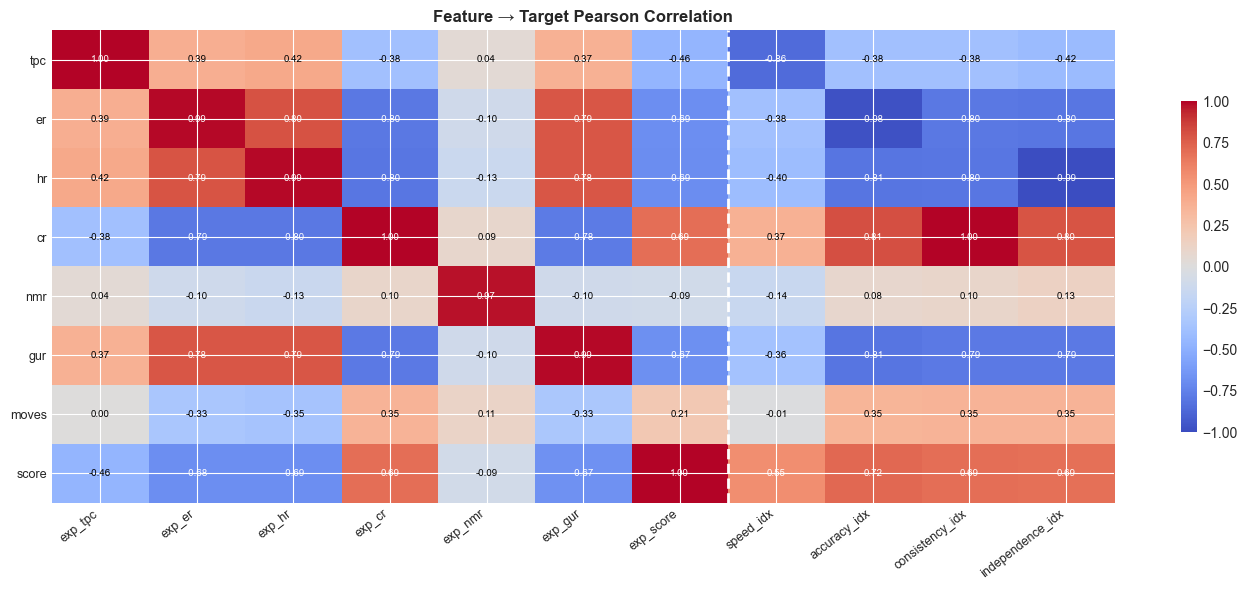


Korelasi tinggi |r| > 0.80 :
  tpc      → exp_tpc                 r=0.995
  tpc      → speed_idx               r=-0.858
  er       → exp_er                  r=0.988
  er       → accuracy_idx            r=-0.976
  hr       → exp_hr                  r=0.989
  hr       → exp_cr                  r=-0.802
  hr       → accuracy_idx            r=-0.811
  hr       → consistency_idx         r=-0.802
  hr       → independence_idx        r=-0.989
  cr       → exp_cr                  r=0.998
  cr       → accuracy_idx            r=0.809
  cr       → consistency_idx         r=0.998
  nmr      → exp_nmr                 r=0.974
  gur      → exp_gur                 r=0.987
  gur      → accuracy_idx            r=-0.806
  score    → exp_score               r=0.996


In [4]:
# ═══════════════════════════════════════════════════════════════
# EDA
# ═══════════════════════════════════════════════════════════════

df_X = pd.DataFrame(X, columns=FEATURE_NAMES)
df_Y = pd.DataFrame(Y, columns=TARGET_NAMES)

print('=== Input Feature Statistics ===')
print(df_X.describe().round(3).to_string())

# ── Feature distributions ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Input Feature Distributions', fontsize=13, fontweight='bold')
for i, (col, ax) in enumerate(zip(FEATURE_NAMES, axes.flat)):
    ax.hist(df_X[col], bins=50, color=f'C{i}', alpha=0.76, edgecolor='none')
    mu, sg = df_X[col].mean(), df_X[col].std()
    ax.axvline(mu, color='red', lw=1.5, ls='--')
    ax.set_title(f'{col}  μ={mu:.2f}  σ={sg:.2f}', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Target distributions ──────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Target Distributions (Y)', fontsize=13, fontweight='bold')
for i, (col, ax) in enumerate(zip(TARGET_NAMES, axes.flat)):
    grp = 'Rate (0–1)' if i < 7 else 'Index (0–100)'
    ax.hist(df_Y[col], bins=50, color=f'C{i}', alpha=0.76, edgecolor='none')
    mu = df_Y[col].mean()
    ax.axvline(mu, color='red', lw=1.5, ls='--')
    ax.set_title(f'{col}\n[{grp}]  μ={mu:.2f}', fontsize=8, fontweight='bold')
axes.flat[-1].set_visible(False)
plt.tight_layout(); plt.show()

# ── Feature-Target correlation heatmap ────────────────────────
corr_xt = np.zeros((len(FEATURE_NAMES), len(TARGET_NAMES)))
for i, f in enumerate(FEATURE_NAMES):
    for j, t in enumerate(TARGET_NAMES):
        corr_xt[i, j] = np.corrcoef(df_X[f], df_Y[t])[0, 1]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(corr_xt, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.7)
ax.set_xticks(range(len(TARGET_NAMES)))
ax.set_yticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels(TARGET_NAMES, rotation=38, ha='right', fontsize=9)
ax.set_yticklabels(FEATURE_NAMES, fontsize=9)
for i in range(len(FEATURE_NAMES)):
    for j in range(len(TARGET_NAMES)):
        val = corr_xt[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(val) > 0.55 else 'black')
ax.set_title('Feature → Target Pearson Correlation', fontsize=12, fontweight='bold')
ax.axvline(6.5, color='white', lw=2, ls='--')   # separator rate vs index targets
plt.tight_layout(); plt.show()

print('\nKorelasi tinggi |r| > 0.80 :')
for i, f in enumerate(FEATURE_NAMES):
    for j, t in enumerate(TARGET_NAMES):
        if abs(corr_xt[i, j]) > 0.80:
            print(f'  {f:<8} → {t:<22}  r={corr_xt[i,j]:.3f}')

In [5]:
# ═══════════════════════════════════════════════════════════════
# 3-WAY SPLIT + SCALE + HELPERS
# 60% train | 20% val | 20% test
# ═══════════════════════════════════════════════════════════════

X_tv, X_test, Y_tv, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_tv, Y_tv, test_size=0.25, random_state=42)
# 0.25 × 0.80 = 0.20 dari total

scaler = StandardScaler()
Xtr = scaler.fit_transform(X_train)
Xva = scaler.transform(X_val)
Xte = scaler.transform(X_test)

print(f'Train : {Xtr.shape}')
print(f'Val   : {Xva.shape}')
print(f'Test  : {Xte.shape}')
print(f'\nScaler mean  : {scaler.mean_.round(3)}')
print(f'Scaler scale : {scaler.scale_.round(3)}')

# ── Evaluation helpers ─────────────────────────────────────────

def eval_model(model, Xte, Yte, name, verbose=True):
    """Per-output R², RMSE, MAE. Return (mean_r2, list_r2, list_rmse)."""
    Yp    = model.predict(Xte)
    r2s   = [r2_score(Yte[:,i], Yp[:,i])                         for i in range(Yte.shape[1])]
    rmses = [np.sqrt(mean_squared_error(Yte[:,i], Yp[:,i]))      for i in range(Yte.shape[1])]
    maes  = [mean_absolute_error(Yte[:,i], Yp[:,i])              for i in range(Yte.shape[1])]
    mean_r2 = float(np.mean(r2s))
    if verbose:
        print(f'\n{"="*62}')
        print(f'  {name}')
        print(f'  Mean R²: {mean_r2:.4f}')
        print(f'{"─"*62}')
        for n, r, rm, ma in zip(TARGET_NAMES, r2s, rmses, maes):
            tag = '✅' if r >= 0.80 else ('○' if r >= 0.60 else '⚠')
            bar = '█' * max(0, int(r * 24))
            print(f'  {tag} {n:<22}  R²={r:+.3f}  RMSE={rm:.4f}  MAE={ma:.4f}  {bar}')
    return mean_r2, r2s, rmses


def gap_report(model, Xtr, Ytr, Xva, Yva, label):
    """Train vs val R² gap — deteksi overfit/underfit."""
    r2_tr = r2_score(Ytr, model.predict(Xtr), multioutput='uniform_average')
    r2_va = r2_score(Yva, model.predict(Xva), multioutput='uniform_average')
    gap   = r2_tr - r2_va
    status = '⚠ Overfit' if gap > 0.12 else ('⚠ Underfit' if r2_va < 0.60 else '✅ Balanced')
    print(f'{label:<44}  Train={r2_tr:.4f}  Val={r2_va:.4f}  Gap={gap:.4f}  {status}')
    return r2_tr, r2_va, gap


def quick_r2(model, Xva, Yva):
    return r2_score(Yva, model.predict(Xva), multioutput='uniform_average')


print('\n✓ Split & helpers ready')

Train : (3018, 8)
Val   : (1006, 8)
Test  : (1007, 8)

Scaler mean  : [1.22080e+01 1.78000e-01 1.83000e-01 6.90000e-01 4.62000e-01 3.45000e-01
 2.97800e+01 3.80835e+02]
Scaler scale : [8.50200e+00 1.63000e-01 1.73000e-01 2.88000e-01 2.24000e-01 2.82000e-01
 1.00000e+01 2.89558e+02]

✓ Split & helpers ready


---
## 🌲 RandomForest — Multi-Output Regressor
Mendukung multi-output secara native.  
Feature importance: **Gini impurity** (rata-rata dari 11 output estimator).

RFC Baseline                                  Train=0.9971  Val=0.9809  Gap=0.0163  ✅ Balanced


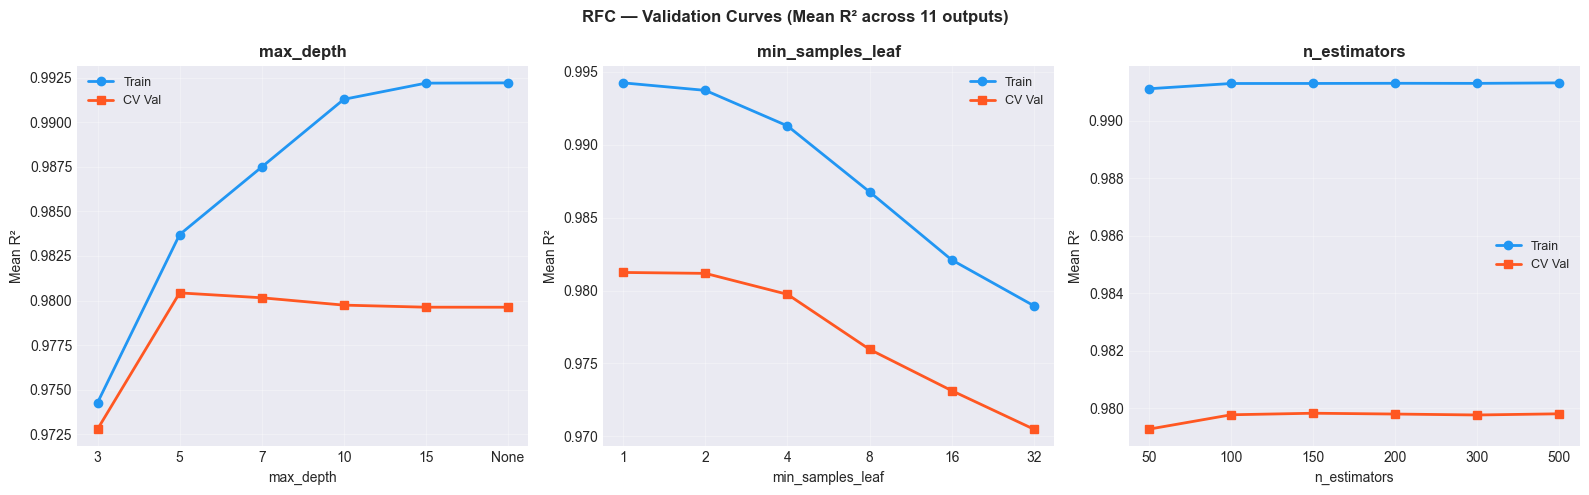

In [6]:
# ═══════════════════════════════════════════════════════════════
# RFC — Baseline + Validation Curves
# ═══════════════════════════════════════════════════════════════

rf_base = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), n_jobs=-1)
rf_base.fit(Xtr, Y_train)
gap_report(rf_base, Xtr, Y_train, Xva, Y_val, 'RFC Baseline')

# ── Validation Curves (manual — lebih fleksibel untuk MultiOutput) ──
def vc_rf(param_name, param_values, fixed=None):
    """Return (tr_r2_list, va_r2_list) untuk satu hyperparameter."""
    if fixed is None: fixed = {}
    tr_r2, va_r2 = [], []
    for v in param_values:
        kw = {'n_estimators': 120, 'max_depth': 10, 'min_samples_leaf': 4,
              'random_state': 42, 'n_jobs': -1, **fixed, **{param_name: v}}
        m = MultiOutputRegressor(RandomForestRegressor(**kw), n_jobs=-1)
        m.fit(Xtr, Y_train)
        tr_r2.append(quick_r2(m, Xtr, Y_train))
        va_r2.append(quick_r2(m, Xva, Y_val))
    return tr_r2, va_r2

params_vc = {
    'max_depth'         : [3, 5, 7, 10, 15, None],
    'min_samples_leaf'  : [1, 2, 4, 8, 16, 32],
    'n_estimators'      : [50, 100, 150, 200, 300, 500],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFC — Validation Curves (Mean R² across 11 outputs)', fontsize=12, fontweight='bold')

for ax, (pname, pvals) in zip(axes, params_vc.items()):
    tr, va = vc_rf(pname, pvals)
    xlbls = [str(v) if v is not None else 'None' for v in pvals]
    ax.plot(xlbls, tr, 'o-', color='#2196F3', lw=2, label='Train')
    ax.plot(xlbls, va, 's-', color='#FF5722', lw=2, label='CV Val')
    ax.set_title(pname, fontweight='bold')
    ax.set_ylabel('Mean R²')
    ax.set_xlabel(pname)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [7]:
# ── RFC RandomizedSearchCV ─────────────────────────────────────

param_rf = {
    'estimator__n_estimators':      randint(120, 420),
    'estimator__max_depth':         [None, 8, 10, 12, 15, 20],
    'estimator__min_samples_leaf':  randint(2, 16),
    'estimator__min_samples_split': randint(4, 28),
    'estimator__max_features':      ['sqrt', 0.60, 0.70, 0.80],
    'estimator__bootstrap':         [True, False],
    'estimator__max_samples':       [None, 0.70, 0.80, 0.90],
}

rs_rf = RandomizedSearchCV(
    MultiOutputRegressor(RandomForestRegressor(random_state=42, n_jobs=-1), n_jobs=-1),
    param_distributions=param_rf,
    n_iter=40, cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2', refit=True, random_state=42, n_jobs=-1, verbose=1)

rs_rf.fit(Xtr, Y_train)
best_rf = rs_rf.best_estimator_

print(f'\nBest CV R²  : {rs_rf.best_score_:.4f}')
print('Best params :')
for k, v in rs_rf.best_params_.items():
    print(f'  {k:<45}: {v}')

r2_rf_tr, r2_rf_va, gap_rf = gap_report(best_rf, Xtr, Y_train, Xva, Y_val, 'RFC (tuned)')
mean_r2_rf, r2_rf_per, rmse_rf_per = eval_model(best_rf, Xva, Y_val, 'RFC Multi-Output (tuned)')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV R²  : 0.9793
Best params :
  estimator__bootstrap                         : True
  estimator__max_depth                         : None
  estimator__max_features                      : 0.8
  estimator__max_samples                       : 0.9
  estimator__min_samples_leaf                  : 3
  estimator__min_samples_split                 : 4
  estimator__n_estimators                      : 167
RFC (tuned)                                   Train=0.9930  Val=0.9801  Gap=0.0129  ✅ Balanced

  RFC Multi-Output (tuned)
  Mean R²: 0.9801
──────────────────────────────────────────────────────────────
  ✅ exp_tpc                 R²=+0.989  RMSE=0.8836  MAE=0.5895  ███████████████████████
  ✅ exp_er                  R²=+0.976  RMSE=0.0258  MAE=0.0158  ███████████████████████
  ✅ exp_hr                  R²=+0.977  RMSE=0.0272  MAE=0.0166  ███████████████████████
  ✅ exp_cr                  R²=+0.995  RMSE=0.0213  MAE=0.0166  █

---
## 🚀 HistGradientBoosting — Multi-Output Regressor
Dibungkus `MultiOutputRegressor` — melatih 11 estimator secara terpisah.  
Keunggulan: regularisasi `l2`, toleransi missing values, lebih cepat dari classic GBM.  
Feature importance: **Permutation Importance** (tidak ada native `feature_importances_`).

GBM Baseline                                  Train=0.9935  Val=0.9773  Gap=0.0161  ✅ Balanced


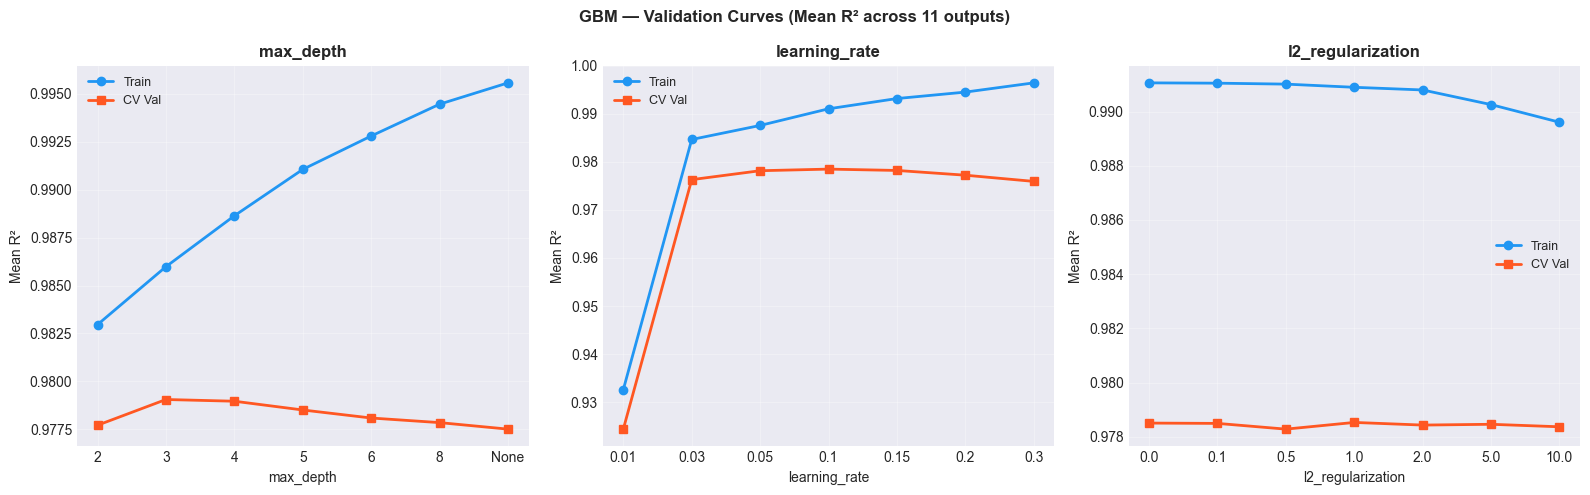

In [8]:
# ═══════════════════════════════════════════════════════════════
# GBM — Baseline + Validation Curves
# ═══════════════════════════════════════════════════════════════

hgb_base = MultiOutputRegressor(
    HistGradientBoostingRegressor(early_stopping=False, random_state=42), n_jobs=-1)
hgb_base.fit(Xtr, Y_train)
gap_report(hgb_base, Xtr, Y_train, Xva, Y_val, 'GBM Baseline')

def vc_hgb(param_name, param_values, fixed=None):
    if fixed is None: fixed = {}
    tr_r2, va_r2 = [], []
    for v in param_values:
        kw = {'max_iter': 150, 'max_depth': 5, 'learning_rate': 0.1,
              'early_stopping': False, 'random_state': 42,
              **fixed, **{param_name: v}}
        m = MultiOutputRegressor(HistGradientBoostingRegressor(**kw), n_jobs=-1)
        m.fit(Xtr, Y_train)
        tr_r2.append(quick_r2(m, Xtr, Y_train))
        va_r2.append(quick_r2(m, Xva, Y_val))
    return tr_r2, va_r2

params_hgb_vc = {
    'max_depth'          : [2, 3, 4, 5, 6, 8, None],
    'learning_rate'      : [0.01, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30],
    'l2_regularization'  : [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('GBM — Validation Curves (Mean R² across 11 outputs)', fontsize=12, fontweight='bold')

for ax, (pname, pvals) in zip(axes, params_hgb_vc.items()):
    tr, va = vc_hgb(pname, pvals)
    xlbls = [str(v) if v is not None else 'None' for v in pvals]
    ax.plot(xlbls, tr, 'o-', color='#2196F3', lw=2, label='Train')
    ax.plot(xlbls, va, 's-', color='#FF5722', lw=2, label='CV Val')
    ax.set_title(pname, fontweight='bold')
    ax.set_ylabel('Mean R²')
    ax.set_xlabel(pname)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [9]:
# ── GBM RandomizedSearchCV ─────────────────────────────────────

param_hgb = {
    'estimator__max_iter':           [100, 150, 200, 300, 400],
    'estimator__max_depth':          [3, 4, 5, 6, 8],
    'estimator__learning_rate':      uniform(0.02, 0.18),
    'estimator__l2_regularization':  uniform(0.01, 3.0),
    'estimator__min_samples_leaf':   randint(8, 45),
    'estimator__max_leaf_nodes':     [20, 31, 40, 50, 63, None],
    'estimator__max_features':       [1.0, 0.80, 0.90],
}

rs_hgb = RandomizedSearchCV(
    MultiOutputRegressor(
        HistGradientBoostingRegressor(early_stopping=False, random_state=42), n_jobs=-1),
    param_distributions=param_hgb,
    n_iter=40, cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2', refit=True, random_state=42, n_jobs=-1, verbose=1)

rs_hgb.fit(Xtr, Y_train)
best_hgb = rs_hgb.best_estimator_

print(f'\nBest CV R²  : {rs_hgb.best_score_:.4f}')
print('Best params :')
for k, v in rs_hgb.best_params_.items():
    print(f'  {k:<45}: {v}')

r2_hgb_tr, r2_hgb_va, gap_hgb = gap_report(best_hgb, Xtr, Y_train, Xva, Y_val, 'GBM (tuned)')
mean_r2_hgb, r2_hgb_per, rmse_hgb_per = eval_model(best_hgb, Xva, Y_val, 'GBM Multi-Output (tuned)')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV R²  : 0.9793
Best params :
  estimator__l2_regularization                 : 0.7653468874760925
  estimator__learning_rate                     : 0.10950473106062938
  estimator__max_depth                         : 3
  estimator__max_features                      : 1.0
  estimator__max_iter                          : 100
  estimator__max_leaf_nodes                    : 20
  estimator__min_samples_leaf                  : 9
GBM (tuned)                                   Train=0.9859  Val=0.9802  Gap=0.0057  ✅ Balanced

  GBM Multi-Output (tuned)
  Mean R²: 0.9802
──────────────────────────────────────────────────────────────
  ✅ exp_tpc                 R²=+0.990  RMSE=0.8813  MAE=0.5797  ███████████████████████
  ✅ exp_er                  R²=+0.975  RMSE=0.0264  MAE=0.0161  ███████████████████████
  ✅ exp_hr                  R²=+0.977  RMSE=0.0275  MAE=0.0166  ███████████████████████
  ✅ exp_cr                  R²=+0.995

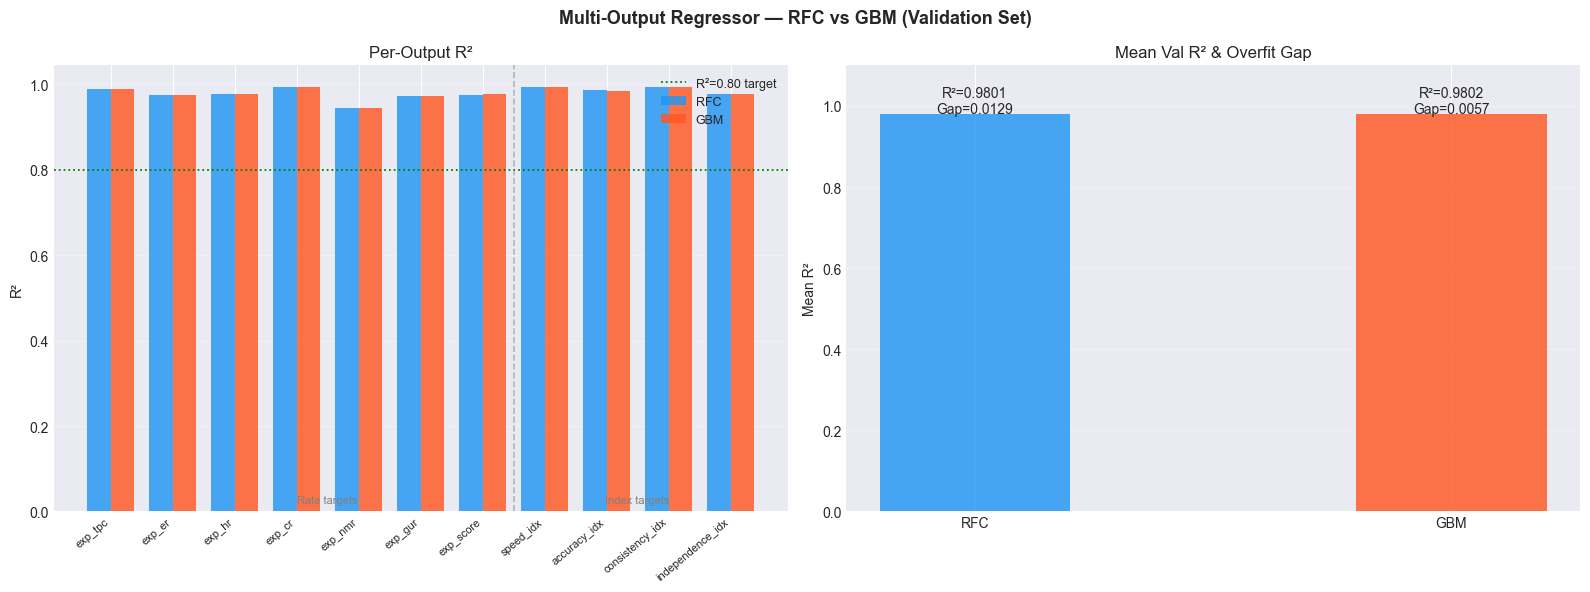


🏆 Winner (val): GBM  (Mean R²=0.9802)


In [10]:
# ═══════════════════════════════════════════════════════════════
# RFC vs GBM — Perbandingan Visual
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Multi-Output Regressor — RFC vs GBM (Validation Set)', fontsize=13, fontweight='bold')

# Per-output R² bar chart
x = np.arange(len(TARGET_NAMES)); w = 0.38
axes[0].bar(x-w/2, r2_rf_per,  w, label='RFC', color='#2196F3', alpha=0.82)
axes[0].bar(x+w/2, r2_hgb_per, w, label='GBM', color='#FF5722', alpha=0.82)
axes[0].axhline(0.80, color='green', lw=1.3, ls=':', label='R²=0.80 target')
axes[0].axhline(0,    color='black', lw=0.6, ls='--')
axes[0].axvline(6.5,  color='gray',  lw=1.2, ls='--', alpha=0.5)  # separator
axes[0].text(3.5, 0.02, 'Rate targets', ha='center', fontsize=8, color='gray')
axes[0].text(8.5, 0.02, 'Index targets', ha='center', fontsize=8, color='gray')
axes[0].set_xticks(x)
axes[0].set_xticklabels(TARGET_NAMES, rotation=40, ha='right', fontsize=8)
axes[0].set_ylabel('R²'); axes[0].set_title('Per-Output R²')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# Summary: mean R² + gap
models    = ['RFC', 'GBM']
val_r2s   = [mean_r2_rf,         mean_r2_hgb]
gaps      = [r2_rf_tr-r2_rf_va,  r2_hgb_tr-r2_hgb_va]
colors    = ['#2196F3', '#FF5722']

b = axes[1].bar(models, val_r2s, color=colors, alpha=0.82, width=0.4)
for bar, g, r in zip(b, gaps, val_r2s):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'R²={r:.4f}\nGap={g:.4f}', ha='center', fontsize=10)
axes[1].set_ylim(0, min(1.1, max(val_r2s)+0.15))
axes[1].set_ylabel('Mean R²'); axes[1].set_title('Mean Val R² & Overfit Gap')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

# Pick winner
winner     = 'RFC' if mean_r2_rf >= mean_r2_hgb else 'GBM'
best_model = best_rf  if winner == 'RFC' else best_hgb
best_r2    = max(mean_r2_rf, mean_r2_hgb)
best_per   = r2_rf_per if winner == 'RFC' else r2_hgb_per

print(f'\n🏆 Winner (val): {winner}  (Mean R²={best_r2:.4f})')

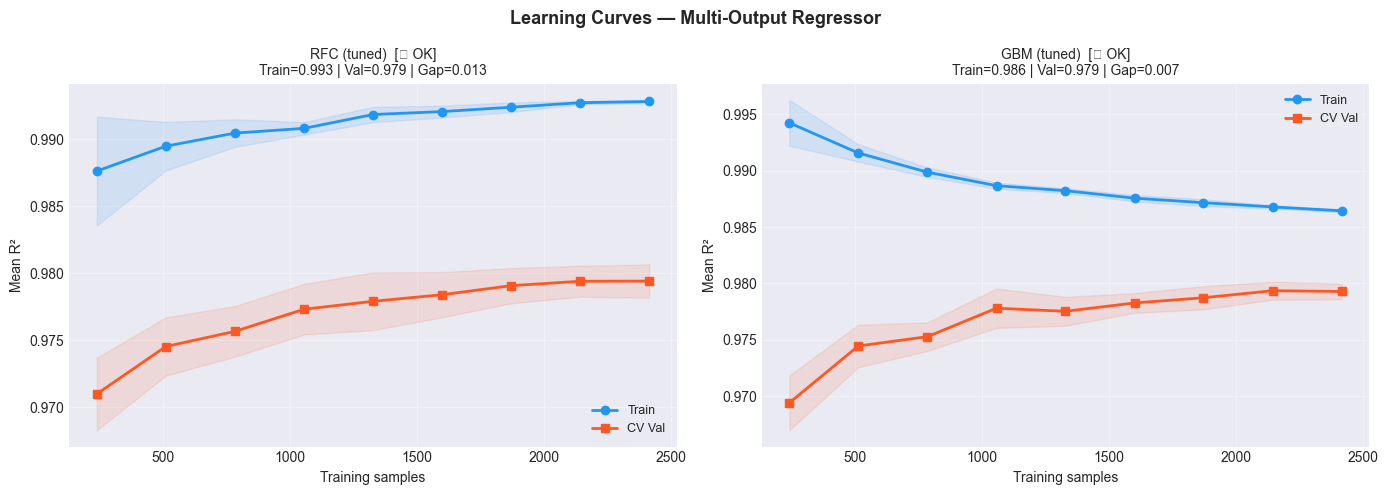

In [11]:
# ═══════════════════════════════════════════════════════════════
# LEARNING CURVES
# ═══════════════════════════════════════════════════════════════

def plot_lc(estimator, X, y, title, ax=None):
    kf    = KFold(n_splits=5, shuffle=True, random_state=42)
    sizes = np.linspace(0.10, 1.0, 9)
    tr_sz, tr_sc, va_sc = learning_curve(
        estimator, X, y,
        train_sizes=sizes, cv=kf,
        scoring='r2', n_jobs=-1,
        shuffle=True, random_state=42)

    tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
    va_m, va_s = va_sc.mean(1), va_sc.std(1)
    gap = tr_m[-1] - va_m[-1]

    own = ax is None
    if own: _, ax = plt.subplots(figsize=(7, 5))

    ax.plot(tr_sz, tr_m, 'o-', color='#2196F3', lw=2, label='Train')
    ax.fill_between(tr_sz, tr_m-tr_s, tr_m+tr_s, alpha=0.12, color='#2196F3')
    ax.plot(tr_sz, va_m, 's-', color='#FF5722', lw=2, label='CV Val')
    ax.fill_between(tr_sz, va_m-va_s, va_m+va_s, alpha=0.12, color='#FF5722')

    status = '⚠ Overfit' if gap > 0.12 else ('⚠ Underfit' if va_m[-1] < 0.60 else '✅ OK')
    ax.set_title(f'{title}  [{status}]\nTrain={tr_m[-1]:.3f} | Val={va_m[-1]:.3f} | Gap={gap:.3f}',
                 fontsize=10)
    ax.set_xlabel('Training samples'); ax.set_ylabel('Mean R²')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    if own: plt.tight_layout(); plt.show()
    return tr_m[-1], va_m[-1], gap


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves — Multi-Output Regressor', fontsize=13, fontweight='bold')
plot_lc(best_rf,  Xtr, Y_train, 'RFC (tuned)',  ax=axes[0])
plot_lc(best_hgb, Xtr, Y_train, 'GBM (tuned)', ax=axes[1])
plt.tight_layout(); plt.show()

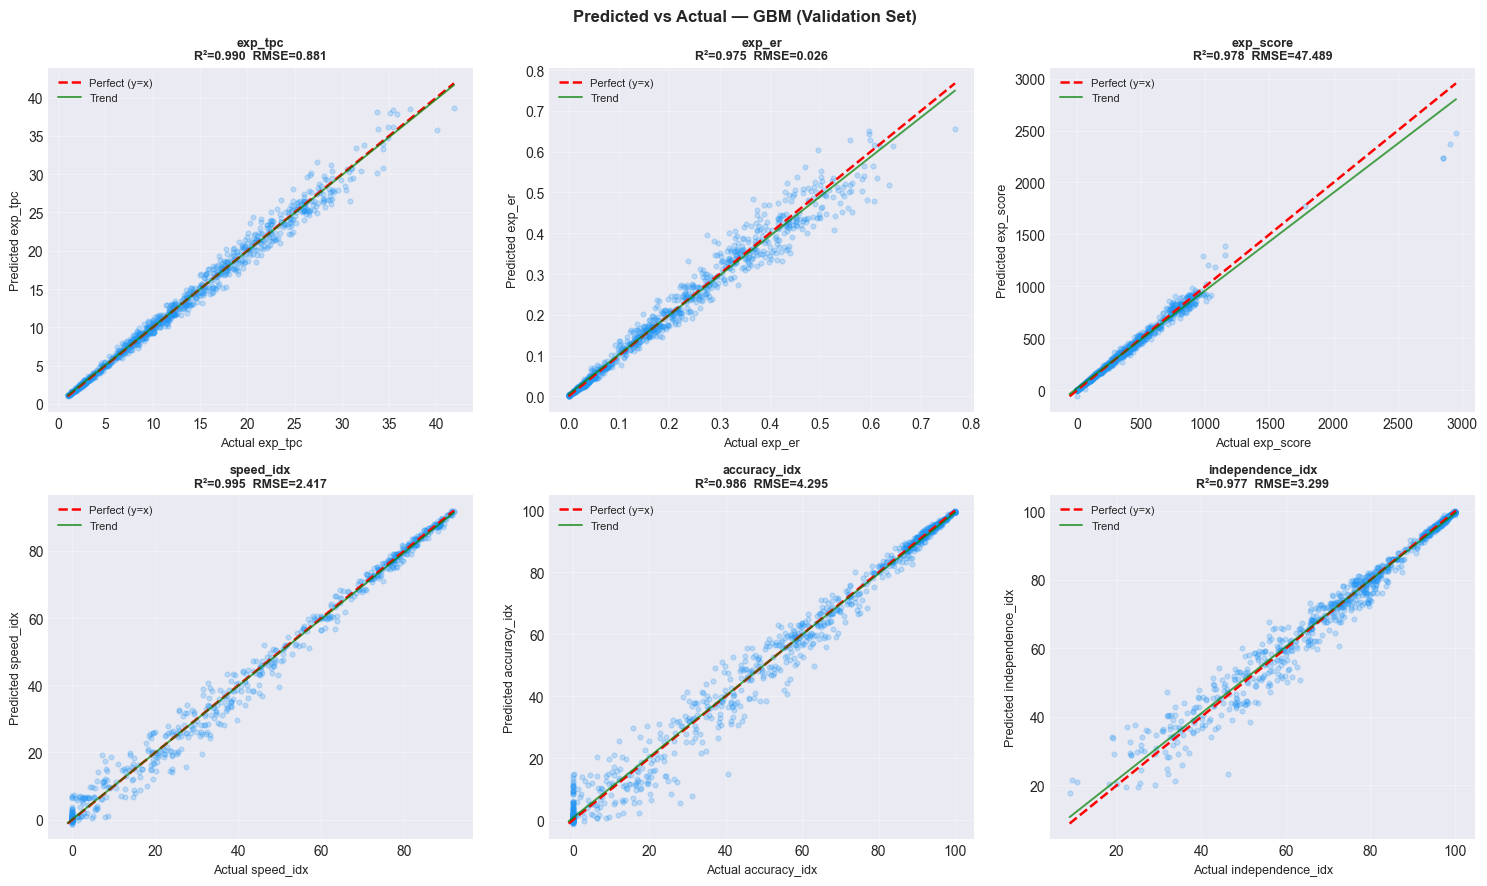

In [12]:
# ═══════════════════════════════════════════════════════════════
# PREDICTED vs ACTUAL — Scatter Plots (sample 6 outputs)
# ═══════════════════════════════════════════════════════════════

Yp_va = best_model.predict(Xva)

sample_targets = [
    'exp_tpc', 'exp_er', 'exp_score',
    'speed_idx', 'accuracy_idx', 'independence_idx'
]
sample_idx = [TARGET_NAMES.index(t) for t in sample_targets]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(f'Predicted vs Actual — {winner} (Validation Set)',
             fontsize=12, fontweight='bold')

for ax, i, name in zip(axes.flat, sample_idx, sample_targets):
    y_true = Y_val[:, i]
    y_pred = Yp_va[:, i]
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    ax.scatter(y_true, y_pred, alpha=0.22, s=12, color='#2196F3', rasterized=True)
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.8, label='Perfect (y=x)')

    # Trend line
    z = np.polyfit(y_true, y_pred, 1)
    p = np.poly1d(z)
    xs = np.linspace(lo, hi, 100)
    ax.plot(xs, p(xs), 'g-', lw=1.4, alpha=0.7, label='Trend')

    ax.set_xlabel(f'Actual {name}', fontsize=9)
    ax.set_ylabel(f'Predicted {name}', fontsize=9)
    ax.set_title(f'{name}\nR²={r2:.3f}  RMSE={rmse:.3f}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

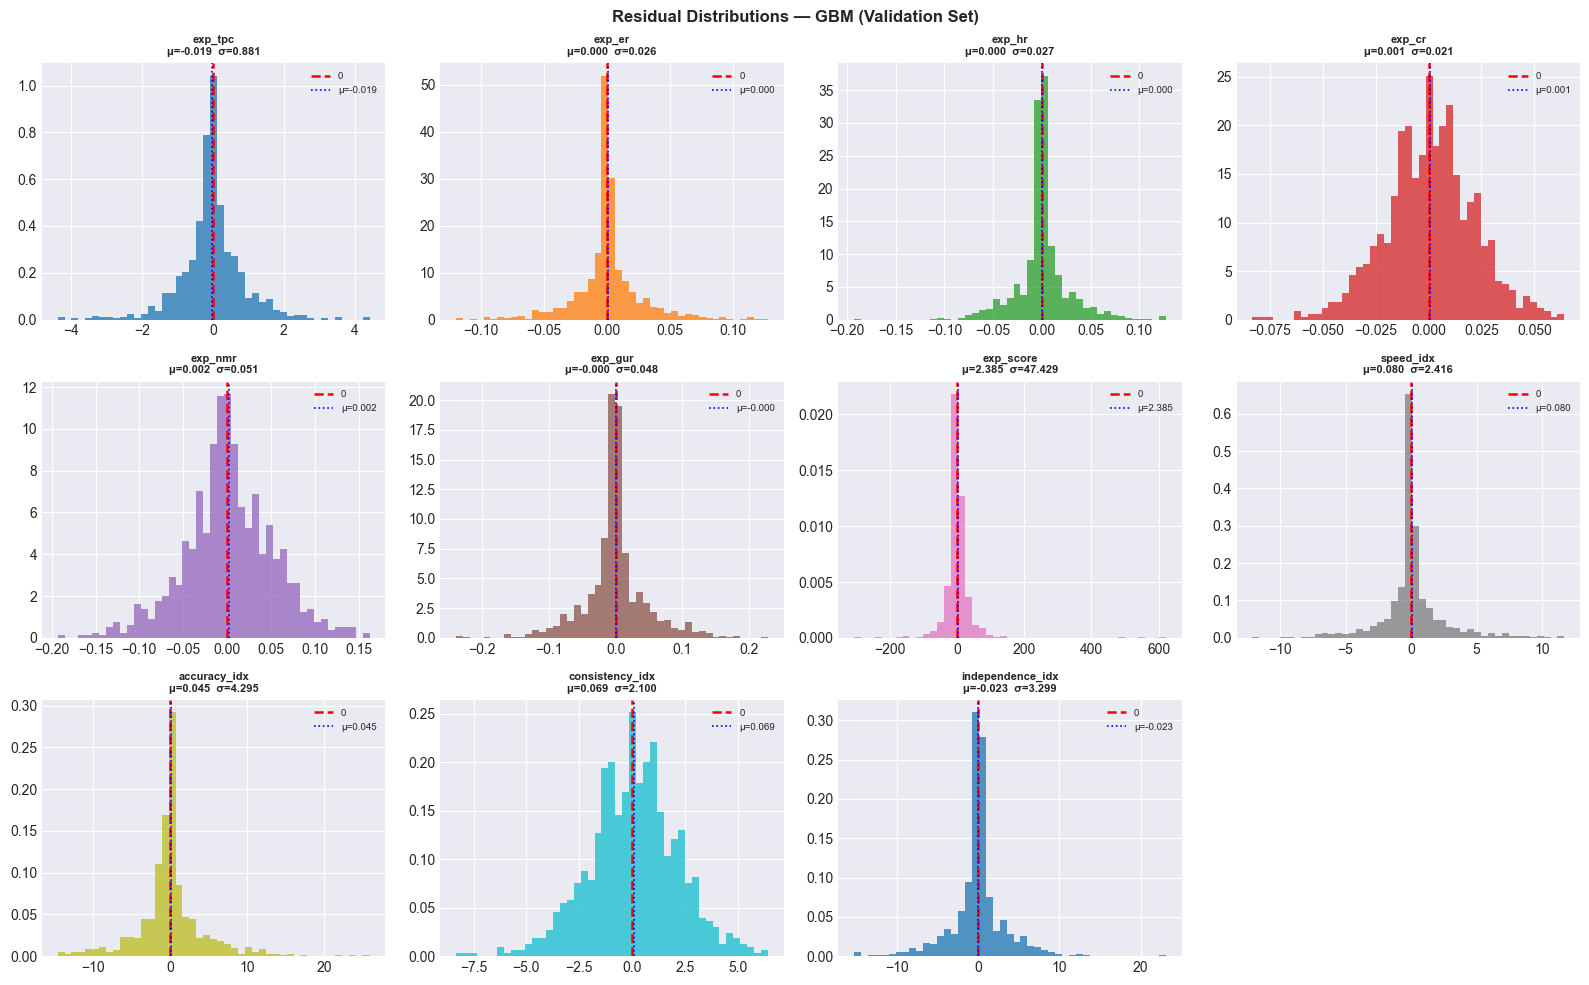

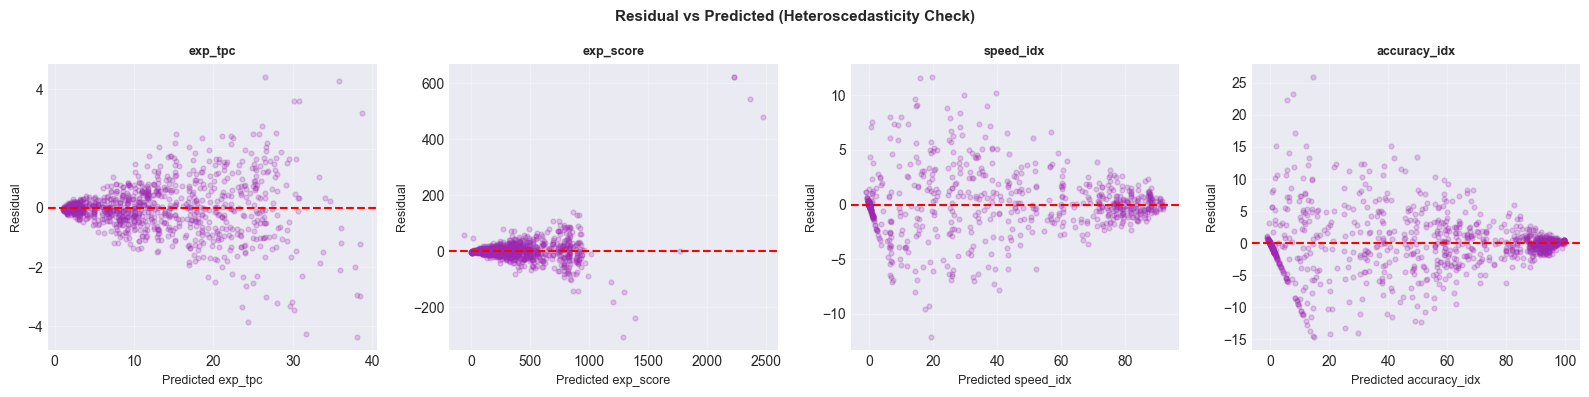

=== Residual Summary ===
Target                       Mean        Std    Max|Res|
────────────────────────────────────────────────────────
✅ exp_tpc                   -0.0190     0.8811      4.4224
✅ exp_er                     0.0004     0.0264      0.1277
✅ exp_hr                     0.0002     0.0275      0.1930
✅ exp_cr                     0.0007     0.0210      0.0834
✅ exp_nmr                    0.0022     0.0508      0.1933
✅ exp_gur                   -0.0003     0.0481      0.2399
✅ exp_score                  2.3848    47.4289    622.5212
✅ speed_idx                  0.0801     2.4161     12.1320
✅ accuracy_idx               0.0445     4.2952     25.9366
✅ consistency_idx            0.0691     2.1000      8.3406
✅ independence_idx          -0.0225     3.2985     23.1566


In [13]:
# ═══════════════════════════════════════════════════════════════
# RESIDUAL ANALYSIS
# Residual ideal: terpusat di 0, distribusi normal
# ═══════════════════════════════════════════════════════════════

residuals = Y_val - Yp_va   # shape (n_val, 11)

# ── Residual distributions ─────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle(f'Residual Distributions — {winner} (Validation Set)', fontsize=12, fontweight='bold')

for i, (ax, name) in enumerate(zip(axes.flat, TARGET_NAMES)):
    res = residuals[:, i]
    ax.hist(res, bins=45, color=f'C{i}', alpha=0.76, edgecolor='none', density=True)
    ax.axvline(0,       color='red',    lw=1.8, ls='--', label='0')
    ax.axvline(res.mean(), color='blue', lw=1.2, ls=':', label=f'μ={res.mean():.3f}')
    ax.set_title(f'{name}\nμ={res.mean():.3f}  σ={res.std():.3f}', fontsize=8, fontweight='bold')
    ax.legend(fontsize=7)

axes.flat[-1].set_visible(False)
plt.tight_layout(); plt.show()

# ── Residual vs Predicted (heteroscedasticity check) ──────────
sample_tgt = ['exp_tpc', 'exp_score', 'speed_idx', 'accuracy_idx']
sample_idx = [TARGET_NAMES.index(t) for t in sample_tgt]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Residual vs Predicted (Heteroscedasticity Check)', fontsize=11, fontweight='bold')

for ax, i, name in zip(axes, sample_idx, sample_tgt):
    ax.scatter(Yp_va[:, i], residuals[:, i], alpha=0.22, s=12, color='#9C27B0', rasterized=True)
    ax.axhline(0, color='red', lw=1.5, ls='--')
    ax.set_xlabel(f'Predicted {name}', fontsize=9)
    ax.set_ylabel('Residual', fontsize=9)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ── Summary statistics ─────────────────────────────────────────
print('=== Residual Summary ===')
print(f'{"Target":<22}  {"Mean":>9}  {"Std":>9}  {"Max|Res|":>10}')
print('─' * 56)
for i, name in enumerate(TARGET_NAMES):
    res = residuals[:, i]
    bias  = '✅' if abs(res.mean()) < 0.05 * (Y_val[:, i].max() - Y_val[:, i].min() + 1e-9) else '⚠'
    print(f'{bias} {name:<22}  {res.mean():>9.4f}  {res.std():>9.4f}  {np.abs(res).max():>10.4f}')

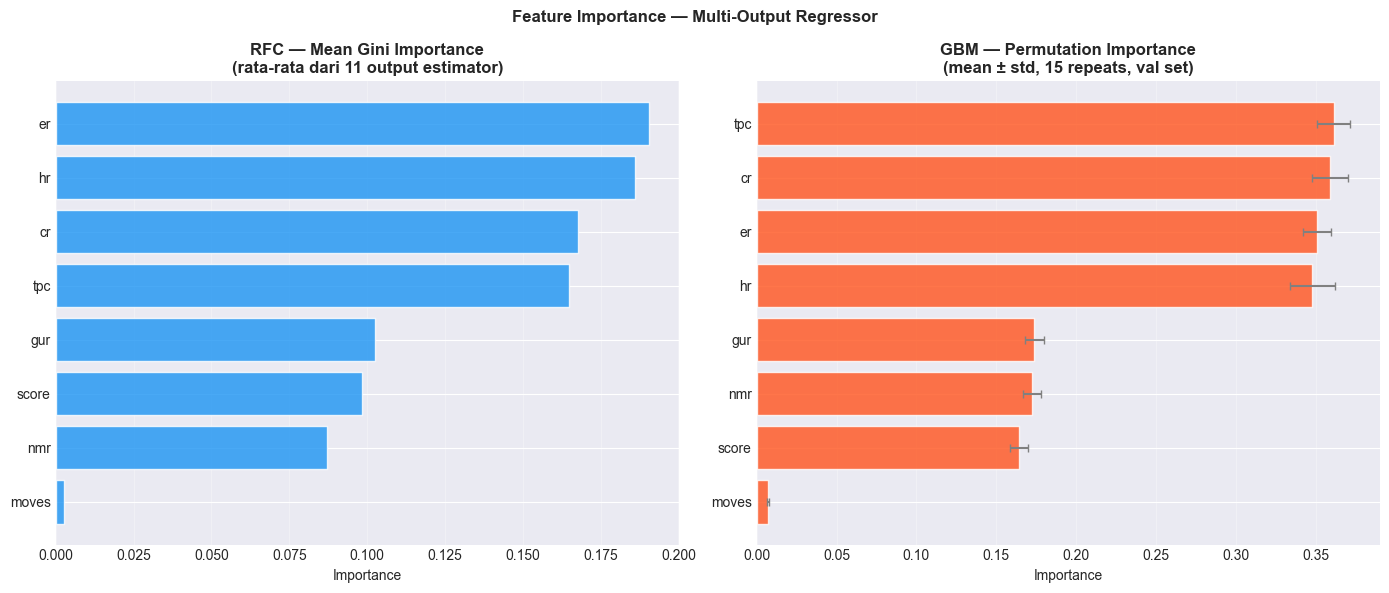

=== Feature Importance ===
         RFC_Gini  GBM_Perm  GBM_Perm_std
Feature                                  
er         0.1907    0.3510        0.0089
hr         0.1862    0.3479        0.0141
cr         0.1677    0.3592        0.0114
tpc        0.1650    0.3615        0.0103
gur        0.1027    0.1738        0.0059
score      0.0982    0.1641        0.0057
nmr        0.0870    0.1724        0.0056
moves      0.0025    0.0071        0.0008


In [14]:
# ═══════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE
# RFC: mean Gini across 11 output-specific RF estimators
# GBM: permutation importance on validation set
# ═══════════════════════════════════════════════════════════════

# RFC native importance
imp_rf = np.mean(
    [e.feature_importances_ for e in best_rf.estimators_], axis=0)

# GBM permutation importance
perm = permutation_importance(
    best_hgb, Xva, Y_val,
    n_repeats=15, random_state=42, n_jobs=-1)
imp_hgb = perm.importances_mean
imp_hgb_std = perm.importances_std

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Importance — Multi-Output Regressor', fontsize=12, fontweight='bold')

def _bar_h(ax, vals, errs, labels, title, color):
    idx = np.argsort(vals)
    ax.barh(
        [labels[i] for i in idx], [vals[i] for i in idx],
        xerr=[errs[i] for i in idx] if errs is not None else None,
        color=color, alpha=0.82, edgecolor='white',
        ecolor='gray', capsize=3)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)

_bar_h(axes[0], imp_rf,  None,         FEATURE_NAMES,
       'RFC — Mean Gini Importance\n(rata-rata dari 11 output estimator)', '#2196F3')
_bar_h(axes[1], imp_hgb, imp_hgb_std, FEATURE_NAMES,
       'GBM — Permutation Importance\n(mean ± std, 15 repeats, val set)', '#FF5722')

plt.tight_layout(); plt.show()

# Table
imp_df = pd.DataFrame({
    'Feature':    FEATURE_NAMES,
    'RFC_Gini':   imp_rf.round(4),
    'GBM_Perm':   imp_hgb.round(4),
    'GBM_Perm_std': imp_hgb_std.round(4),
}).set_index('Feature').sort_values('RFC_Gini', ascending=False)

print('=== Feature Importance ===')
print(imp_df.to_string())

=== FINAL TEST EVALUATION — GBM ===
Test set benar-benar held-out (tidak dipakai saat tuning)


  GBM — FINAL TEST
  Mean R²: 0.9802
──────────────────────────────────────────────────────────────
  ✅ exp_tpc                 R²=+0.989  RMSE=0.8945  MAE=0.5714  ███████████████████████
  ✅ exp_er                  R²=+0.976  RMSE=0.0260  MAE=0.0149  ███████████████████████
  ✅ exp_hr                  R²=+0.977  RMSE=0.0269  MAE=0.0151  ███████████████████████
  ✅ exp_cr                  R²=+0.995  RMSE=0.0208  MAE=0.0164  ███████████████████████
  ✅ exp_nmr                 R²=+0.948  RMSE=0.0505  MAE=0.0363  ██████████████████████
  ✅ exp_gur                 R²=+0.974  RMSE=0.0453  MAE=0.0282  ███████████████████████
  ✅ exp_score               R²=+0.972  RMSE=50.5430  MAE=21.8955  ███████████████████████
  ✅ speed_idx               R²=+0.995  RMSE=2.4130  MAE=1.3264  ███████████████████████
  ✅ accuracy_idx            R²=+0.986  RMSE=4.1625  MAE=2.4296  ███████████████████████
  ✅ consist

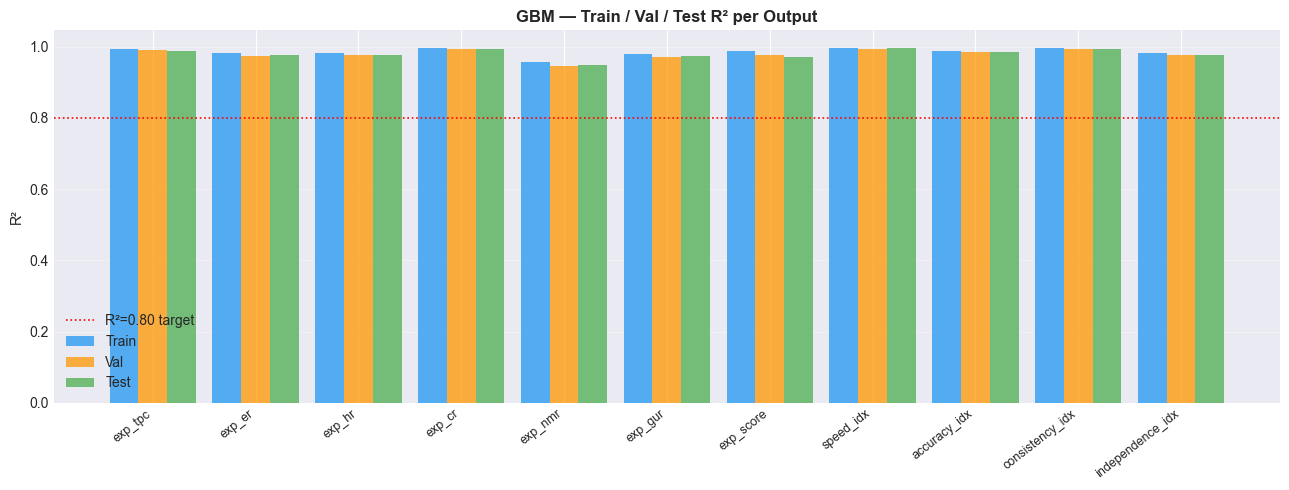

In [15]:
# ═══════════════════════════════════════════════════════════════
# FINAL TEST SET EVALUATION (held-out — tidak pernah disentuh)
# ═══════════════════════════════════════════════════════════════

print(f'=== FINAL TEST EVALUATION — {winner} ===')
print('Test set benar-benar held-out (tidak dipakai saat tuning)\n')

r2_tr_final = r2_score(Y_train, best_model.predict(Xtr), multioutput='uniform_average')
r2_va_final = r2_score(Y_val,   best_model.predict(Xva), multioutput='uniform_average')
r2_te_final, r2_te_per, rmse_te_per = eval_model(
    best_model, Xte, Y_test, f'{winner} — FINAL TEST', verbose=True)

gap_cv_te = r2_tr_final - r2_te_final

print(f'\n{"─"*45}')
print(f'  Train R²      : {r2_tr_final:.4f}')
print(f'  Val   R²      : {r2_va_final:.4f}')
print(f'  Test  R²      : {r2_te_final:.4f}')
print(f'  Train–Test Gap: {gap_cv_te:.4f}')
print(f'  Overfit check : {"✅ PASS" if gap_cv_te <= 0.12 else "⚠  FAIL"}')
print(f'  Underfit check: {"✅ PASS" if r2_te_final >= 0.60 else "⚠  FAIL"}')

# Visualisasi train/val/test R² per output
r2_val_best = [r2_score(Y_val[:,i], best_model.predict(Xva)[:,i]) for i in range(11)]

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(TARGET_NAMES)); w = 0.28
ax.bar(x-w, [r2_score(Y_train[:,i], best_model.predict(Xtr)[:,i]) for i in range(11)],
       w, label='Train', color='#2196F3', alpha=0.75)
ax.bar(x,   r2_val_best, w, label='Val',   color='#FF9800', alpha=0.75)
ax.bar(x+w, r2_te_per,   w, label='Test',  color='#4CAF50', alpha=0.75)
ax.axhline(0.80, color='red', lw=1.2, ls=':', label='R²=0.80 target')
ax.axhline(0,    color='black', lw=0.5, ls='--')
ax.set_xticks(x)
ax.set_xticklabels(TARGET_NAMES, rotation=38, ha='right', fontsize=9)
ax.set_ylabel('R²'); ax.set_title(f'{winner} — Train / Val / Test R² per Output', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [16]:
# ═══════════════════════════════════════════════════════════════
# SAVE MODELS  (format kompatibel dengan Sudoku.py)
# ═══════════════════════════════════════════════════════════════

PKL_DIR = Path("Models")
PKL_DIR.mkdir(parents=True, exist_ok=True)

def save_pkl(name, obj):
    path = PKL_DIR / name
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    size = path.stat().st_size / 1024
    print(f'✓ {name:<20} ({size:.1f} KB)')


print('=== Saving PKL ===')

# ── Multioutput_regressor_GBM.pkl — model terbaik (kompatibel Sudoku.py) ──────────
save_pkl('Multioutput_regressor_GBM.pkl', {
    'model':  best_model,
    'scaler': scaler,
    'r2':     r2_te_final,
})

=== Saving PKL ===
✓ Multioutput_regressor_GBM.pkl (1782.8 KB)


In [17]:
# ── Verification ─────────────────────────────────────────────
print('=== Verification ===')
with open(PKL_DIR / 'Multioutput_regressor_GBM.pkl', 'rb') as f:
    pkg = pickle.load(f)

sample_x  = pkg['scaler'].transform(X_test[:5])
sample_y  = pkg['model'].predict(sample_x)

print(f'Output shape     : {sample_y.shape}  (5 samples × 11 targets)')
print(f'speed_idx        : {sample_y[:, 7].round(1)}')
print(f'accuracy_idx     : {sample_y[:, 8].round(1)}')
print(f'consistency_idx  : {sample_y[:, 9].round(1)}')
print(f'independence_idx : {sample_y[:,10].round(1)}')

=== Verification ===
Output shape     : (5, 11)  (5 samples × 11 targets)
speed_idx        : [32.1 10.9 -0.1 84.8 -0. ]
accuracy_idx     : [66.  33.9 89.1 99.6 79.9]
consistency_idx  : [99.1 71.9 96.6 99.9 90.3]
independence_idx : [77.1 80.7 99.8 99.6 97.1]
